# GLiNER2.5-Decide under the sysone head

> A decision model that reads its own labels, run on its authors' benchmark three ways: as they run it, through sysone's GLiNER2 backend, and with its encoder under the sysone head, first zero-shot and then with the head trained.

- skip_exec: true
- skip_showdoc: true

[GLiNER2.5-Decide](https://huggingface.co/fastino/GLiNER2.5-Decide) (Fastino, Apache-2.0) is a 340-million-parameter encoder, DeBERTa-v3-large, trained to make decisions. You give it a text and one or more *heads*. A head is a name and a set of labels, such as `urgency: low, normal, high, critical`. The model writes the head into the same row of tokens as the text, with a marker token, `[L]`, in front of each label:

```
( [P] urgency ( [L] low [L] normal [L] high [L] critical ) ) [SEP_TEXT] my card was charged twice and …
```

It reads the row once. Because the labels sit in the row, each `[L]` vector has read the label that follows it *and* the text. A small MLP turns each `[L]` vector into a score, and a softmax over the scores gives the probabilities. That is the shape of the sysone head, too, with `[L]` in the part that `[MASK]` plays for ModernBERT: an anchor token in front of each option, scored by a small network. So sysone can use this model in two ways:

- **The GLiNER2 backend** (`sysone.gliner`, the `gliner` extra) runs the whole model through its own package, `gliner2`, and answers in the Jev schema like every other sysone model.
- **The text application** (`sysone.text`) loads only the encoder, with transformers, and puts it under the sysone head. `head="gliner2"` gives the head the classifier's shape, and `init_from` copies the classifier's weights in, so the model answers before any training. The encoder then stays frozen, and the head trains on cached anchor vectors like any other.

This notebook runs both on [fast-decisions](https://huggingface.co/datasets/fastino/fast-decisions), the benchmark Fastino built for the model: 17 domains of operational decisions, from support intents and email triage to ticket routing and clinic requests. It checks how closely the two routes agree before any training, then trains the head on half of each domain and scores it on the other half, beside a new head and beside ModernBERT-large, the text application's default encoder.

::: {.callout-tip title="Jargon"}
- **Head**: in GLiNER2, one classification task, a name and its labels. In sysone, the small network on top of the encoder that scores the options. One GLiNER2 head becomes one sysone *choice* question.
- **Zero-shot**: answering with no training on this task's examples.
- **Warm start**: starting a model's weights from another trained model's weights, here the head from GLiNER2's classifier, instead of from random numbers.
- **Frozen encoder, cached anchors**: when only the head trains, the encoder's vector at each anchor never changes, so sysone computes it once and stores it. Training then reads the stored vectors, which takes seconds.
- **Development and test splits**: Fastino publishes 100 rows per domain (the development split) and keeps 300 per domain hidden to report its scores on (the test split). Everything here runs on the published 100, so none of these numbers is the benchmark's score.
- **Exact match**: a head counts as right when the predicted label is the gold label.
:::

::: {.callout-note title="Running this notebook"}
The test suite skips this notebook (`skip_exec`). It downloads GLiNER2.5-Decide (1.95 GB), the benchmark's development split (1.9 MB) and ModernBERT-large (1.6 GB), and the GLiNER2 part needs sysone's `gliner` extra, which the next cell installs when it's missing. One model is in memory at a time. The whole run takes about 19 minutes on an M3 Pro (MPS, fp32), and the outputs below come from a run on 2026-09-29. It keeps its feature cache in `gliner-decide/`, next to the notebook.
:::

In [ ]:
#| eval: false
# The GLiNER2 backend needs sysone's `gliner` extra: the gliner2 package, and peft.
import importlib.util, shutil, subprocess, sys
if any(importlib.util.find_spec(p) is None for p in ("gliner2", "peft")):   # install into this kernel's environment, with uv when there is one
    installer = ["uv", "pip", "install", "--python", sys.executable] if shutil.which("uv") else [sys.executable, "-m", "pip", "install"]
    subprocess.run(installer + ["-q", "gliner2>=2.0", "peft>=0.20"], check=True)

In [ ]:
import gc, json, logging, random, resource, sys, time, warnings
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
import datasets, transformers
from huggingface_hub import snapshot_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from gliner2 import AutoExtractor
from sysone.data import TypedDecisions
from sysone.gliner import GlinerDecider
from sysone.text import decision_learner, ENCODER

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=r".*torch\.jit\.script", category=FutureWarning)   # DeBERTa-v2's modeling code on Python 3.14
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20); pd.set_option("display.max_colwidth", 90)
DECIDE = "fastino/GLiNER2.5-Decide"
work = Path("gliner-decide")
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted models"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def memory_line():
    "The process's peak resident memory"
    return f"peak memory {resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (2**30 if sys.platform == 'darwin' else 2**20):.1f} GB"

## The benchmark

Each domain is one file of 100 rows. A row is a text and the decisions a product would make about it: each head has a name, its candidate labels and the gold label.

In [ ]:
repo = Path(snapshot_download("fastino/fast-decisions", repo_type="dataset"))
DOMAINS = ["support_intent", "support_topic", "document_type", "review_sentiment", "agent_handoff", "email_triage",
           "ticket_route", "product_feedback", "banking_intent", "clinic_request", "travel_request", "news_topic",
           "paper_field", "sports_recap", "restaurant_review", "benefits_request", "screen_tags"]   # the dataset card's order
rows = {d: [json.loads(l) for l in (repo / f"{d}.jsonl").read_text().splitlines()] for d in DOMAINS}
row = rows["email_triage"][0]
print(row["input"][:420], "…")
pd.DataFrame(row["output"]["classifications"])

From: Lydia Harper <lydia.harper@cogentware.example>
To: admin@impulselectronics.example
Subject: Coordination—rescheduling quarterly review deadline

Hello Admin Team,

Summary: The project review that was previously set for today must be moved to accommodate a late-breaking platform update. We request confirmation for a new time slot before 3 p.m. Eastern today so stakeholders can be notified on schedule. Attached, …


,task,true_label,labels,multi_label
0,category,[calendar],"[billing, support, sales, legal, recruiting, calendar, newsletter, security]",False
1,action,[escalate],"[reply, approve, fyi, escalate]",False
2,needs_reply,[yes],"[yes, no]",False
3,is_phishing,[no],"[yes, no]",False


Every row of a domain carries the same heads. Over the 17 domains there are 29 heads, three of them multi-label: a product review can be about several areas at once, and a film can have several genres.

In [ ]:
heads = pd.DataFrame([{"domain": d, "head": h["task"], "labels": len(h["labels"]), "multi": h["multi_label"]}
                      for d in DOMAINS for h in rows[d][0]["output"]["classifications"]])
assert all([h["task"] for h in r["output"]["classifications"]] == list(heads[heads.domain == d]["head"]) for d in DOMAINS for r in rows[d])
heads.assign(head=heads["head"] + " (" + heads.labels.astype(str) + heads.multi.map({True: ", multi-label", False: ""}) + ")") \
     .groupby("domain", sort=False)["head"].agg(", ".join).to_frame("heads (number of labels)")

,heads (number of labels)
domain,
support_intent,intent (28)
support_topic,topic (12)
document_type,doc_type (12)
review_sentiment,sentiment (3)
agent_handoff,should_handoff (2)
email_triage,"category (8), action (4), needs_reply (2), is_phishing (2)"
ticket_route,"queue (16), urgency (4), contains_pii (2)"
product_feedback,"feedback_type (4), product_area (8, multi-label)"
banking_intent,intent (16)


## GLiNER2, as its authors score it

The dataset card gives the scoring loop: one `classify_text` call per head, with the head's name and labels and nothing else, and the prediction compared with the gold as a set. Here it is as the card writes it, over every head of every row.

In [ ]:
model = AutoExtractor.from_pretrained(DECIDE).to(device).eval()

def card_loop(model, rows) -> dict:
    "The dataset card's loop: {(row id, head): (predicted labels, right?, multi-label?)}"
    out = {}
    for d, rs in rows.items():
        for i, r in enumerate(rs):
            for h in r["output"]["classifications"]:
                got = model.classify_text(r["input"], {h["task"]: h["labels"]})[h["task"]]
                got = [got] if isinstance(got, str) else [got["label"]] if isinstance(got, dict) else list(got or [])
                out[(f"{d}/{i:03d}", h["task"])] = (got, sorted(got) == sorted(h["true_label"]), h["multi_label"])
    return out

t = time.time(); card = card_loop(model, rows); t_card = time.time() - t
card_df = pd.DataFrame([{"domain": k[0].split("/")[0], "right": v[1], "multi": v[2]} for k, v in card.items()])
print(f"{len(card):,} decisions in {t_card / 60:.1f} min ({t_card / len(card) * 1000:.0f} ms each)")
print(f"mean over domains: every head {card_df.groupby('domain').right.mean().mean():.3f}, "
      f"single-label heads {card_df[~card_df.multi].groupby('domain').right.mean().mean():.3f}; "
      f"multi-label heads {card_df[card_df.multi].right.mean():.3f}")

🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-large
Counting layer     : count_lstm
Token pooling      : first
2,900 decisions in 5.8 min (120 ms each)
mean over domains: every head 0.629, single-label heads 0.685; multi-label heads 0.170


/Users/sebastiangonzalezaseretto/computer-science/sysonelib/.venv/lib/python3.14/site-packages/gliner2/models/span/model.py:99: RuntimeWarning: Encoder rejected attn_implementation='sdpa'; falling back to 'eager' (DebertaV2Model does not support an attention implementation through torch.nn.functional.scaled_dot_product_attention yet. Please request the support for this architecture: https://github.com/huggingface/transformers/issues/28005. If you believe this error is a bug, please open an issue in Transformers GitHub repository and load your model with the argument `attn_implementation="eager"` meanwhile. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="eager")`)
  self.encoder = self._load_encoder(


Over every head, scored as the card scores it, the model is right on 0.629 of the decisions, averaged over the domains. The card reports 0.602 on its hidden test split. That's a different set of rows, so the two numbers aren't the same measurement, but they're close. The three multi-label heads pull the average down. The card's loop asks each head for one label, and most of their gold answers have several, so they score 0.17. Over the 26 single-label heads, the mean is 0.685, and that's the number to compare with below, since every sysone question has a single answer. Each call took 120 ms on the laptop's GPU.

## Typed questions

sysone's question types each have a single answer: a *choice* among options, a *score* on a scale, a *noul* (true or false). So each single-label head becomes a choice question, named after the head, and the three multi-label heads are left out of everything that follows. The benchmark gives a head no instructions beyond its name, so the name is the question's instructions too.

In [ ]:
def to_record(d, i, r) -> dict:
    "A row as a sysone record: a choice question per single-label head"
    heads = [h for h in r["output"]["classifications"] if not h["multi_label"]]
    return {"id": f"{d}/{i:03d}", "domain": d, "state": r["input"],
            "questions": {h["task"]: {"type": "choice", "instructions": h["task"], "criteria": h["labels"]} for h in heads},
            "gold": {h["task"]: h["true_label"][0] for h in heads}}

records = [to_record(d, i, r) for d in DOMAINS for i, r in enumerate(rows[d])]
labels = {(r["id"], q): v["criteria"] for r in records for q, v in r["questions"].items()}     # every decision's options, in order
gold = {(r["id"], q): v["criteria"].index(r["gold"][q]) for r in records for q, v in r["questions"].items()}
print(f"{len(records):,} records, {len(gold):,} decisions")
{k: v for k, v in records[500].items() if k != "state"}

1,700 records, 2,600 decisions


{'id': 'email_triage/000',
 'domain': 'email_triage',
 'questions': {'category': {'type': 'choice',
   'instructions': 'category',
   'criteria': ['billing',
    'support',
    'sales',
    'legal',
    'recruiting',
    'calendar',
    'newsletter',
    'security']},
  'action': {'type': 'choice',
   'instructions': 'action',
   'criteria': ['reply', 'approve', 'fyi', 'escalate']},
  'needs_reply': {'type': 'choice',
   'instructions': 'needs_reply',
   'criteria': ['yes', 'no']},
  'is_phishing': {'type': 'choice',
   'instructions': 'is_phishing',
   'criteria': ['yes', 'no']}},
 'gold': {'category': 'calendar',
  'action': 'escalate',
  'needs_reply': 'yes',
  'is_phishing': 'no'}}

## The GLiNER2 backend

`GlinerDecider` wraps the loaded model. For each record, it turns the questions into GLiNER2 heads, runs them, and reads each head's full distribution back into an answer in the Jev schema. Its call differs from the card's in two ways. When a record has several questions, the backend asks them in one call, and GLiNER2 reads them all in one row, one head after another. And each question's instructions become the head's prompt, so GLiNER2 reads `category: category` where the card's loop sends `category` alone.

In [ ]:
backend = GlinerDecider(model)
print(json.dumps(backend.predict(records[500]["state"], records[500]["questions"]), indent=1)[:600])

{
 "category": {
  "type": "choice",
  "choice": "calendar",
  "probabilities": {
   "billing": 0.0347,
   "support": 0.0329,
   "sales": 0.0042,
   "legal": 0.0007,
   "recruiting": 0.0016,
   "calendar": 0.9194,
   "newsletter": 0.0054,
   "security": 0.0011
  },
  "confidence": 0.8171,
  "answer_confidence": 0.9194
 },
 "action": {
  "type": "choice",
  "choice": "reply",
  "probabilities": {
   "reply": 0.6659,
   "approve": 0.111,
   "fyi": 0.1553,
   "escalate": 0.0679
  },
  "confidence": 0.2884,
  "answer_confidence": 0.6659
 },
 "needs_reply": {
  "type": "choice",
  "choice": "yes",



In [ ]:
t = time.time()
preds = {"GLiNER2 backend": {(r["id"], q): labels[(r["id"], q)].index(a["choice"])
                             for r in records for q, a in backend.predict(r["state"], r["questions"]).items()}}
t_backend = time.time() - t
card_pred = {k: labels[k].index(card[k][0][0]) if card[k][0] and card[k][0][0] in labels[k] else -1 for k in gold}
same = np.mean([preds["GLiNER2 backend"][k] == card_pred[k] for k in gold])
print(f"{len(gold):,} decisions in {t_backend / 60:.1f} min · the same label as the card's loop on {same:.1%} of them")
del model, backend; release()

2,600 decisions in 3.6 min · the same label as the card's loop on 92.9% of them


The backend gives the card's label on 92.9% of the decisions, and it's slightly more accurate: 0.693 against 0.685 on the mean over domains (the results table below). The two differences in the call account for the rest. Asked one question per call, with no instructions, the backend makes exactly the card's call and gives the card's label on all 2,600 decisions (the [GLiNER backend](../31_gliner_backend.ipynb#glinerdecider) notebook has that check).

## The encoder under the sysone head

Now the text application. Only the encoder is loaded, with transformers: the span and count heads GLiNER2 uses for extraction are dropped, and the classifier's two layers are copied into the sysone head. Everything else is the application as it runs on any encoder: the `gliner` template writes the row in GLiNER2's layout, the encoder runs once over every row, and the head reads the `[L]` anchors.

The data is split in two halves, 50 rows of every domain in each. The head trains on one half and is scored on the other, then the halves swap, so every decision gets a prediction from a head that never saw it.

In [ ]:
def halves(records, seed=0):
    "Two halves of the records, 50 rows of every domain in each"
    by = defaultdict(list)
    for r in records: by[r["domain"]].append(r)
    a, b = [], []
    for d in DOMAINS:
        rs = by[d][:]; random.Random(f"{seed}:{d}").shuffle(rs)
        a += rs[:len(rs) // 2]; b += rs[len(rs) // 2:]
    return a, b

half_a, half_b = halves(records)
FOLDS = [(half_a, half_b), (half_b, half_a)]

def answers(learn) -> dict:
    "The predicted option of every held-out decision, from the cached anchors"
    p, ds = learn.get_preds("valid"), learn.dataset("valid")
    return {(c, q): int(i) for c, q, i in zip(ds["case"], ds["qid"], p["logits"].argmax(-1))}

One row as the encoder reads it. sysone's `gliner` template writes the question's type, *choice*, where GLiNER2 writes the head's name, and the name follows as the question's instructions:

In [ ]:
data = TypedDecisions(half_a, valid=half_b)
learn = quiet(decision_learner(data, DECIDE, head="gliner2", init_from=DECIDE, cache_dir=work))
print(learn)
learn.show_batch(1, split="valid", max_chars=320)

Learner(fastino/GLiNER2.5-Decide · regime head · head 0 layers/gliner2 · cache masks · loss soft_ce · 2,104,321 of 436,025,345 params train)
([P] choice: intent ([L] order_status[L] refund_request[L] cancel_subscription[L] update_payment[L] login_problem[L] password_reset[L] shipping_delay[L] missing_item[L] damaged_item[L] change_address[L] change_ord …  my billing or shipping preferences. I'm uncertain about the benefits but willing to make a change swiftly.
markers [6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50, 54, 58, 62, 66, 70, 74, 80, 82, 86, 90, 92, 94, 98, 102, 106, 110] · qtype choice · 248 tokens



### How fast to train

fastai's way to pick a learning rate is `lr_find`: train for 100 steps while the rate grows from 10⁻⁷ to 1, record the loss, and suggest a rate from the curve. Its *valley* suggestion is the middle of the longest stretch over which the loss keeps falling. Here are the curves for a new head on each encoder's anchors, on the first training half, each run twice with the batches drawn in two different orders:

both encoders' training anchors cached, and four curves drawn, in 3.5 min


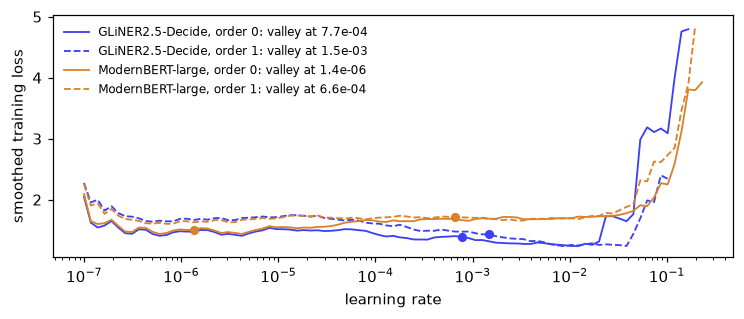

In [ ]:
def lr_curve(encoder, seed):
    "lr_find's curve and suggestions for a new head on `encoder`'s cached anchors of the first training half, batches drawn in `seed`'s order"
    lf = quiet(decision_learner(TypedDecisions(half_a, valid=half_b), encoder, cache_dir=work, seed=seed))
    sugg = lf.lr_find(); curve = lf.lr_curve
    del lf; release()
    return curve, sugg

t = time.time()
curves = {(name, seed): lr_curve(enc, seed) for name, enc in (("GLiNER2.5-Decide", DECIDE), ("ModernBERT-large", ENCODER)) for seed in (0, 1)}
print(f"both encoders' training anchors cached, and four curves drawn, in {(time.time() - t) / 60:.1f} min")
fig, ax = plt.subplots(figsize=(7, 3))
for (name, seed), ((lrs, losses), sugg) in curves.items():
    color = "#3b3ff5" if name == "GLiNER2.5-Decide" else "#d9822b"
    ax.plot(lrs, losses, color=color, ls="-" if seed == 0 else "--", lw=1.2, label=f"{name}, order {seed}: valley at {sugg.valley:.1e}")
    ax.plot([sugg.valley], [np.interp(np.log(sugg.valley), np.log(lrs), losses)], "o", color=color, ms=5)
ax.set(xscale="log", xlabel="learning rate", ylabel="smoothed training loss"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

All four curves drop in their first few steps, at rates far too small for a head to learn anything. That's the smoothed loss settling after its first batches, which are noisy: four rows each, with 2 to 28 options. After that, the loss of the Decide head falls between about 10⁻⁴ and 10⁻², and then blows up. Its valley lands in that fall, at 7.7·10⁻⁴ or 1.5·10⁻³ depending on the order. ModernBERT's head barely learns in 100 steps, so its curve stays flat until it blows up, and the valley lands wherever the noise draws the longest descent. In one order that's 1.4·10⁻⁶, far too small to train anything in four epochs, and in the other it's 6.6·10⁻⁴. A suggestion from `lr_find` is a heuristic read off a noisy curve, so look at the curve before you use it.

So every head here trains the same way: `fit_one_cycle(4, lr=1e-3)`, four passes over the training half with the rate warming up to 10⁻³ and then annealing, the rate the image tutorials train their heads at. Each fold trains three heads. Two are on the Decide encoder: GLiNER2's classifier, starting from its copied weights, and a new head on the same cached anchors. The third is a new head on ModernBERT-large, with ModernBERT's own template and its `[MASK]` anchors. Before training, the copied classifier also answers the held-out half as it is, which gives the zero-shot row.

In [ ]:
fold_start = time.time()
for fold, (train, test) in enumerate(FOLDS):
    if fold: data = TypedDecisions(train, valid=test); learn = quiet(decision_learner(data, DECIDE, head="gliner2", init_from=DECIDE, cache_dir=work))
    preds.setdefault("Decide, its classifier, zero-shot", {}).update(answers(learn))
    learn.fit_one_cycle(4, lr=1e-3)
    preds.setdefault("Decide, its classifier, trained", {}).update(answers(learn))
    del learn; release()

    learn = quiet(decision_learner(data, DECIDE, cache_dir=work))             # a new head, on the same cached anchors
    learn.fit_one_cycle(4, lr=1e-3)
    preds.setdefault("Decide, a new head", {}).update(answers(learn))
    del learn, data; release()

    learn = quiet(decision_learner(TypedDecisions(train, valid=test), ENCODER, cache_dir=work))   # ModernBERT-large
    learn.fit_one_cycle(4, lr=1e-3)
    preds.setdefault("ModernBERT-large, a new head", {}).update(answers(learn))
    del learn; release()
    print(f"fold {fold + 1} of 2 done · {(time.time() - fold_start) / 60:.1f} min · {memory_line()}")

fold 1 of 2 done · 4.1 min · peak memory 4.4 GB
fold 2 of 2 done · 5.5 min · peak memory 4.4 GB


## Results

Accuracy on the 26 single-label heads: the mean over the 17 domains, as the card reports it, and over all 2,600 decisions. The last column is how often a model picks the same label as GLiNER2 does in the card's loop.

In [ ]:
def summary(p:dict) -> dict:
    right = pd.Series({k: p[k] == gold[k] for k in gold})
    by_domain = right.groupby([k[0].split("/")[0] for k in right.index]).mean()
    return {"mean over domains": by_domain.mean(), "all decisions": right.mean(), "same label as the card's loop": np.mean([p[k] == card_pred[k] for k in gold])}

preds = {"the card's loop": card_pred} | preds
table = pd.DataFrame({name: summary(p) for name, p in preds.items()}).T
table.style.format("{:.3f}")

,mean over domains,all decisions,same label as the card's loop
the card's loop,0.685,0.665,1.000
GLiNER2 backend,0.693,0.675,0.929
"Decide, its classifier, zero-shot",0.684,0.665,0.950
"Decide, its classifier, trained",0.684,0.667,0.913
"Decide, a new head",0.690,0.670,0.901
"ModernBERT-large, a new head",0.420,0.429,0.482


- **One model, three ways.** The card's loop, the GLiNER2 backend and the Decide encoder with the classifier copied into the sysone head all score within a point of each other, and the copied classifier gives the card's label on 95% of the decisions. That checks the text application's route: the encoder loaded with transformers alone, plus two layers copied from the checkpoint, reproduce GLiNER2.5-Decide. The [GLiNER encoder](../30_gliner_encoder.ipynb#the-template) notebook shows what closes most of the last 5%: a row written closer to GLiNER2's own.
- **Training the head adds almost nothing here.** Trained on 50 rows of every domain, GLiNER2's classifier scores what it scored before, 0.684, though its answers drift away from GLiNER2's (91% the same, down from 95%). A new head on the same anchors gains six tenths of a point. With a few dozen examples per domain, there's little for a head to learn that the model's own post-training hasn't already taught it.
- **The encoder is what matters.** A new head learns to read the Decide encoder's `[L]` vectors from 1,300 decisions as well as GLiNER2's own classifier does. On ModernBERT-large's `[MASK]` vectors, the same head scores 0.420: ModernBERT was never trained to put a decision into its anchors, and 1,300 examples over 17 domains are too few to find one there.

In [ ]:
per_domain = pd.DataFrame({name: pd.Series({k: p[k] == gold[k] for k in gold}).groupby([k[0].split("/")[0] for k in gold]).mean()
                           for name, p in preds.items()}).loc[DOMAINS]
per_domain.insert(0, "decisions", pd.Series([k[0].split("/")[0] for k in gold]).value_counts())
per_domain.style.format("{:.2f}", subset=list(preds)).background_gradient(cmap="Blues", subset=list(preds), vmin=0, vmax=1)

,decisions,the card's loop,GLiNER2 backend,"Decide, its classifier, zero-shot","Decide, its classifier, trained","Decide, a new head","ModernBERT-large, a new head"
support_intent,100,0.76,0.75,0.75,0.75,0.76,0.25
support_topic,100,0.44,0.45,0.45,0.45,0.49,0.27
document_type,100,0.79,0.79,0.78,0.79,0.78,0.67
review_sentiment,100,0.84,0.84,0.84,0.86,0.86,0.45
agent_handoff,100,0.76,0.81,0.73,0.73,0.75,0.57
email_triage,400,0.59,0.59,0.58,0.59,0.59,0.43
ticket_route,300,0.48,0.50,0.51,0.51,0.49,0.30
product_feedback,100,0.74,0.74,0.75,0.75,0.75,0.45
banking_intent,100,0.64,0.63,0.64,0.64,0.66,0.23
clinic_request,200,0.65,0.66,0.66,0.66,0.66,0.47


Domain by domain, the Decide rows move together, mostly within a few points of each other, and the hard domains are hard for all of them: `support_topic` (0.44 to 0.49), `paper_field` (0.46 to 0.48) and `ticket_route` (0.48 to 0.51). The new head gains most on `benefits_request`, `support_topic` and `travel_request`, four to six points, and both trained heads lose most on `screen_tags`, whose film-or-series head drops from 0.83 to 0.77 and 0.78. ModernBERT-large's head keeps up only on that head, and falls furthest where a head has many labels: 0.25 on the 28 support intents, and 0.20 on the 12 travel intents.

## What this shows

- **Which route to use.** Both routes run the same model. The GLiNER2 backend keeps everything GLiNER2 has: its extraction features (entities, relations, structured records), its constrained decoding over several heads, and its own trainer. The text application gives the model sysone's machinery: cached features, heads that train in seconds, calibrated temperatures, the act head, and the export. It runs on transformers alone, with no `gliner2` package.
- **A decision-tuned encoder beats a trained head.** On this benchmark, the choice of encoder moved accuracy by 27 points, and training the head moved it by less than one. It's the same on sysone's own benchmark, typed-decisions, where a new head on the Decide encoder scores 0.645, against 0.504 on ModernBERT-large and 0.560 on Laya's encoder (the [text notebook's table](../10_text.ipynb#regimes-on-the-laptop)).
- **What would move these numbers.** More examples per domain, or training the encoder itself (`train="lora"`). The two held-out halves are the way to measure either.
- **Caveats.** These are the 100 published rows of each domain, not the hidden 300 the card's scores come from, and each head trained on half of them. A domain's accuracy rests on its 100 rows, a standard error of about 0.05, so small differences between domains, and between the Decide rows, are noise. The three multi-label heads are left out, because sysone has no multi-label question type.

In [ ]:
print(f"the whole notebook: {(time.time() - t_start) / 60:.1f} minutes · {memory_line()}")

the whole notebook: 18.8 minutes · peak memory 4.4 GB
